# Import libraries and load cleaned data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('../data/processed/movies_cleaned.csv')

# chart 1: distribution of ratings & popularity

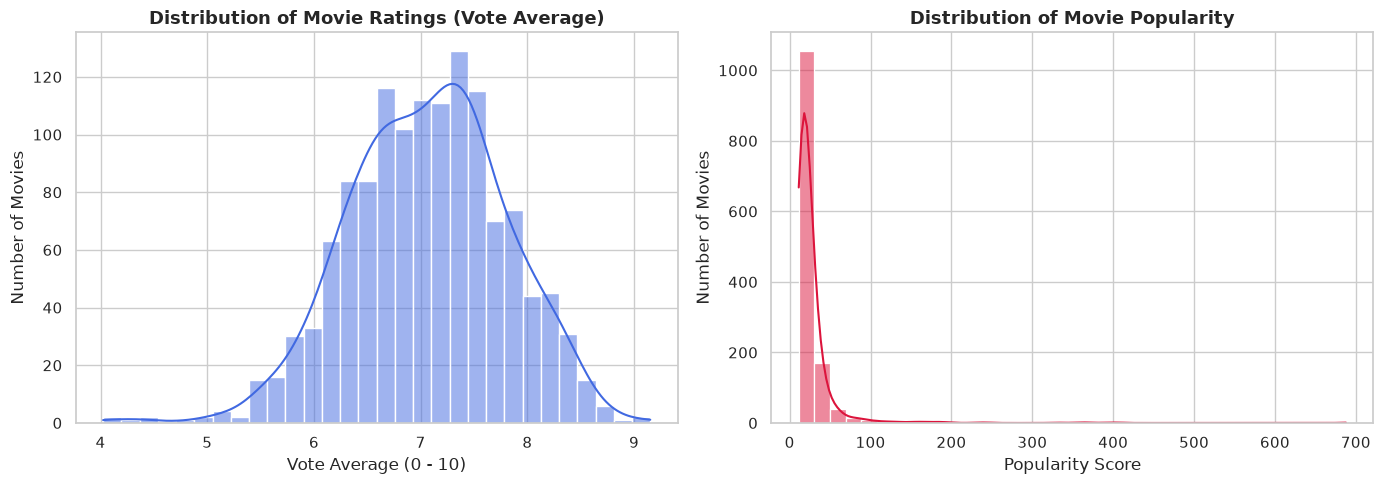

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Create figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Ratings distribution
sns.histplot(data=df, x="vote_average", kde=True, ax=axes[0], color="royalblue", bins=30)
axes[0].set_title("Distribution of Movie Ratings (Vote Average)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Vote Average (0 - 10)")
axes[0].set_ylabel("Number of Movies")

# Plot 2: Popularity distribution
sns.histplot(data=df, x="popularity", kde=True, ax=axes[1], color="crimson", bins=35)
axes[1].set_title("Distribution of Movie Popularity", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Popularity Score")
axes[1].set_ylabel("Number of Movies")

plt.tight_layout()
plt.show()

Interpretation:

Ratings (vote_average): Shows a roughly bell-shaped (normal) distribution centered around 6.5–7.0. Very few films score below 4.0 or above 8.5.
Popularity: Highly right-skewed with a long tail. The vast majority of films cluster at lower popularity scores (< 50), while only a small handful of blockbuster titles reach extreme popularity values.

# chart2: films per genre

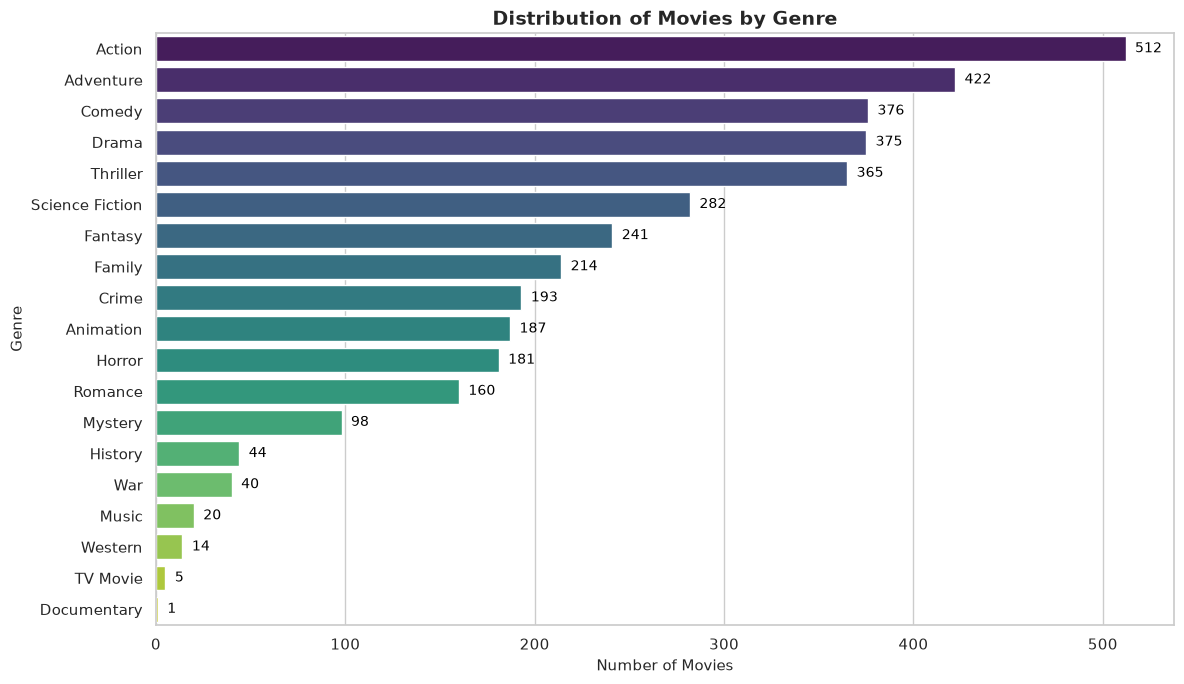

In [4]:
# 1. Calculate genre counts
genre_counts = df["genres"].dropna().str.split(", ").explode().value_counts()

# 2. Create the horizontal bar plot
plt.figure(figsize=(12, 7))
sns.barplot(
    x=genre_counts.values, 
    y=genre_counts.index, 
    palette="viridis",
    hue=genre_counts.index,
    legend=False
)

# 3. Add titles and labels
plt.title("Distribution of Movies by Genre", fontsize=14, fontweight="bold")
plt.xlabel("Number of Movies", fontsize=11)
plt.ylabel("Genre", fontsize=11)

# Annotate each bar with the exact count
for index, value in enumerate(genre_counts.values):
    plt.text(value + 5, index, str(value), va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

Interpretation:

Dominant Genres: Action (512) and Adventure (422) are the most prominent genres in the catalog, followed by Comedy (376) and Drama (375).
Commercial catalog bias: Because TMDB's popular list heavily reflects commercial cinema and streaming interest, high-spectacle genres (Action, Adventure, Sci-Fi) appear far more frequently than niche categories (Documentary, Western, War).

# chart 3: Movie releases per year

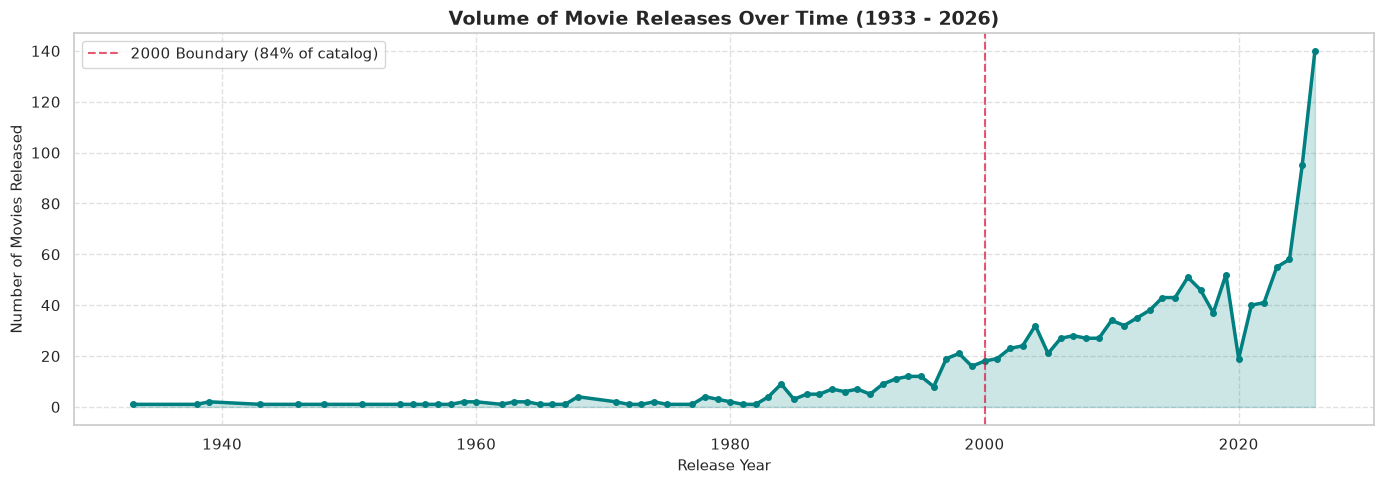

In [5]:
# 1. Extract the release year
df["release_year"] = pd.to_datetime(df["release_date"]).dt.year

# 2. Count releases per year sorted chronologically
releases_per_year = df["release_year"].value_counts().sort_index()

# 3. Create the trend plot
plt.figure(figsize=(14, 5))
plt.plot(releases_per_year.index, releases_per_year.values, color="teal", linewidth=2.5, marker="o", markersize=4)
plt.fill_between(releases_per_year.index, releases_per_year.values, color="teal", alpha=0.2)

# Highlight modern era (2000 onwards)
plt.axvline(x=2000, color="crimson", linestyle="--", alpha=0.7, label="2000 Boundary (84% of catalog)")

# Labels and styling
plt.title("Volume of Movie Releases Over Time (1933 - 2026)", fontsize=14, fontweight="bold")
plt.xlabel("Release Year", fontsize=11)
plt.ylabel("Number of Movies Released", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

Interpretation:

Heavy Recency Bias: Over 84% of the catalog (1,105 movies) was released between the year 2000 and 2026, with release counts surging exponentially over the last two decades.
Selective Vintage Classics: Pre-1990 films make up only 6.6% of the catalog, representing only the most enduring historic classics that still retain high viewer engagement today (e.g. The Godfather, Star Wars).
Impact on Feature Engineering: Because exact year varies wildly, in Step 4 we will bucket movies into decades (release_decade, e.g. 80s, 90s, 2010s, 2020s) to give our Machine Learning models a cleaner, generalized temporal feature.

# chart 4: runtime distibution (duree)

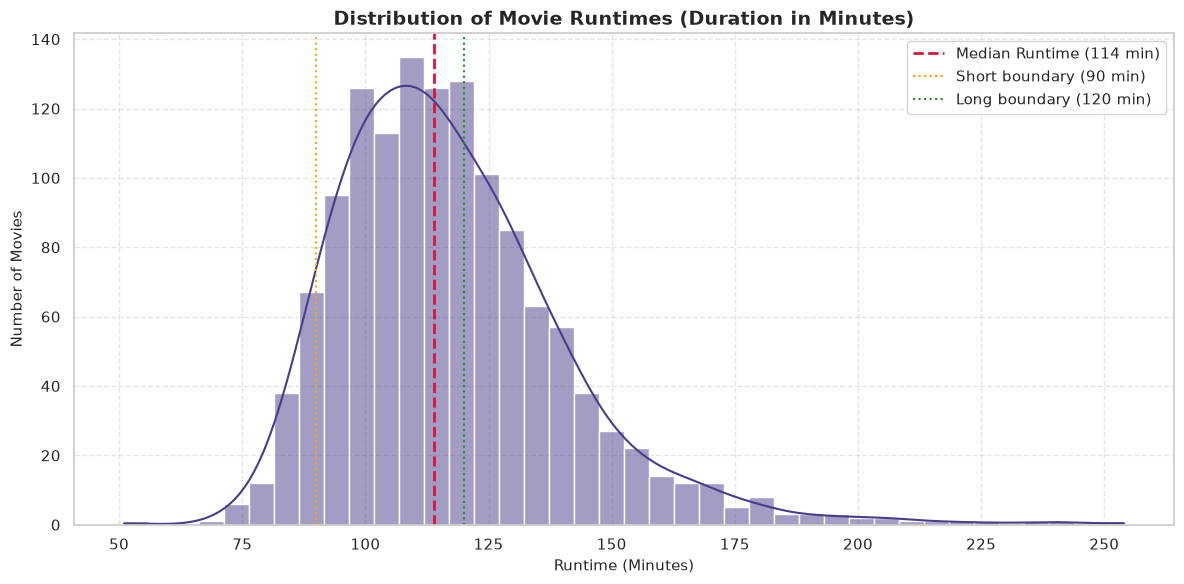

In [6]:
plt.figure(figsize=(12, 6))

# Histogram with KDE curve
sns.histplot(data=df, x="runtime", kde=True, color="darkslateblue", bins=40)

# Add reference lines
median_rt = df["runtime"].median()
plt.axvline(median_rt, color="crimson", linestyle="--", linewidth=2, label=f"Median Runtime ({median_rt:.0f} min)")
plt.axvline(90, color="orange", linestyle=":", linewidth=1.5, label="Short boundary (90 min)")
plt.axvline(120, color="forestgreen", linestyle=":", linewidth=1.5, label="Long boundary (120 min)")

# Titles and labels
plt.title("Distribution of Movie Runtimes (Duration in Minutes)", fontsize=14, fontweight="bold")
plt.xlabel("Runtime (Minutes)", fontsize=11)
plt.ylabel("Number of Movies", fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Interpretation:

Central Tendency: Movie runtimes cluster strongly around a median of 114 minutes (~1h54m). The bulk of commercial films adhere strictly to the 90–120 minute commercial standard (54.6% of the catalog).
Extended Blockbusters: Over 38% of the films exceed 2 hours, reflecting the popularity of modern action, superhero, and sci-fi franchises which demand longer runtimes.
Feature Engineering Justification: Confirms that binning runtime into 3 discrete categories (Short < 90m, Standard 90-120m, Long > 120m) is statistically justified for Step 4.

# chart 5: budget vs revenue (box office ROI)

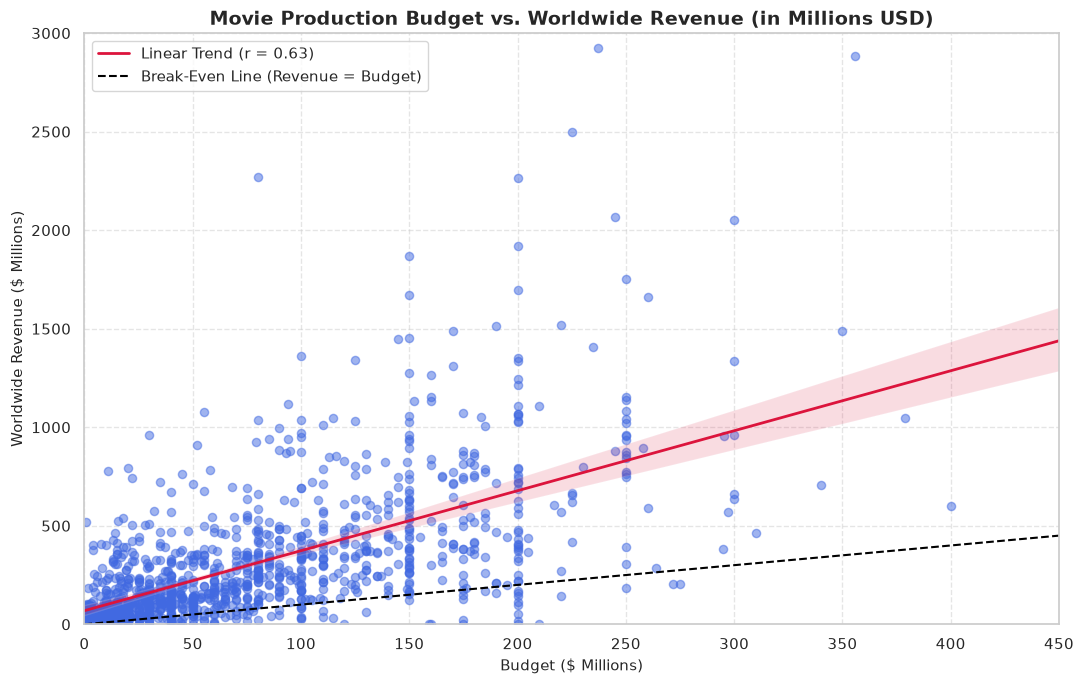

In [7]:
# 1. Filter out movies with missing/zero financial data (in millions)
fin_df = df[(df["budget"] > 0) & (df["revenue"] > 0)].copy()
fin_df["budget_m"] = fin_df["budget"] / 1e6
fin_df["revenue_m"] = fin_df["revenue"] / 1e6

# 2. Scatter plot with regression line
plt.figure(figsize=(11, 7))
sns.regplot(
    data=fin_df, 
    x="budget_m", 
    y="revenue_m",
    scatter_kws={"alpha": 0.5, "color": "royalblue", "s": 35},
    line_kws={"color": "crimson", "linewidth": 2, "label": "Linear Trend (r = 0.63)"}
)

# 3. Add diagonal break-even line (y = x)
max_val = max(fin_df["budget_m"].max(), fin_df["revenue_m"].max())
plt.plot([0, 450], [0, 450], color="black", linestyle="--", linewidth=1.5, label="Break-Even Line (Revenue = Budget)")

# Labels and limits
plt.title("Movie Production Budget vs. Worldwide Revenue (in Millions USD)", fontsize=14, fontweight="bold")
plt.xlabel("Budget ($ Millions)", fontsize=11)
plt.ylabel("Worldwide Revenue ($ Millions)", fontsize=11)
plt.xlim(0, 450)
plt.ylim(0, 3000)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation - Chart 5:
- **Strong Positive Correlation (r = 0.63)**: There is a clear upward trend showing that higher production budgets generally yield higher worldwide revenues. Studio tentpoles (> $150M) consistently reach top-tier revenues.
- **Commercial Profitability**: The vast majority of movies sit comfortably above the dashed break-even line ($y = x$), indicating positive commercial return across the catalog.
- **Flops & Outliers**: A few notable films fall below the break-even line, confirming that high financial investment does not always guarantee audience turnout.

# Chart 6: Votes Count vs. Popularity

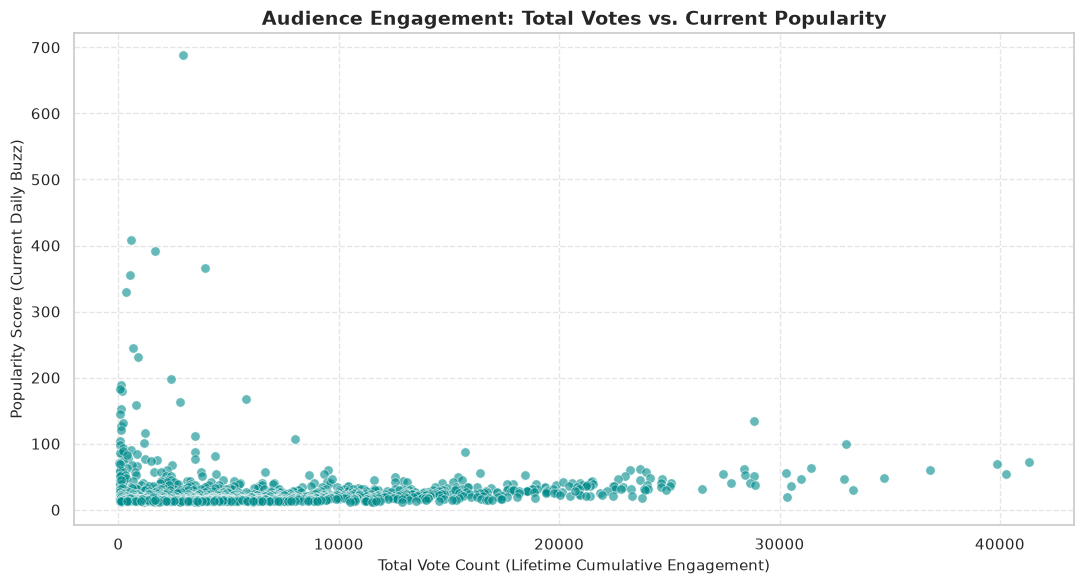

In [8]:
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=df,
    x="vote_count",
    y="popularity",
    alpha=0.6,
    color="darkcyan",
    s=45
)

plt.title("Audience Engagement: Total Votes vs. Current Popularity", fontsize=14, fontweight="bold")
plt.xlabel("Total Vote Count (Lifetime Cumulative Engagement)", fontsize=11)
plt.ylabel("Popularity Score (Current Daily Buzz)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation - Chart 6:
- **Decoupled Metrics (Near-Zero Correlation r ≈ 0.00)**: Lifetime votes and current popularity measure two fundamentally different dimensions of engagement.
- **Lifetime Engagement vs. Daily Buzz**: Historical classics (e.g. *Inception*, *The Dark Knight*) have accumulated 30,000+ votes over 15 years but have moderate current popularity (~20–40). Conversely, brand-new releases have viral daily buzz (popularity > 300) with only modest initial vote counts.
- **Target Selection Justification for Step 6**: This validates using `vote_count` rather than `popularity` as the foundation for our `high_engagement` classification target, as lifetime vote count reflects lasting, proven audience interest.

# Chart 7: Boxplots & Correlation Heatmap

/tmp/ipykernel_51484/2907970724.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


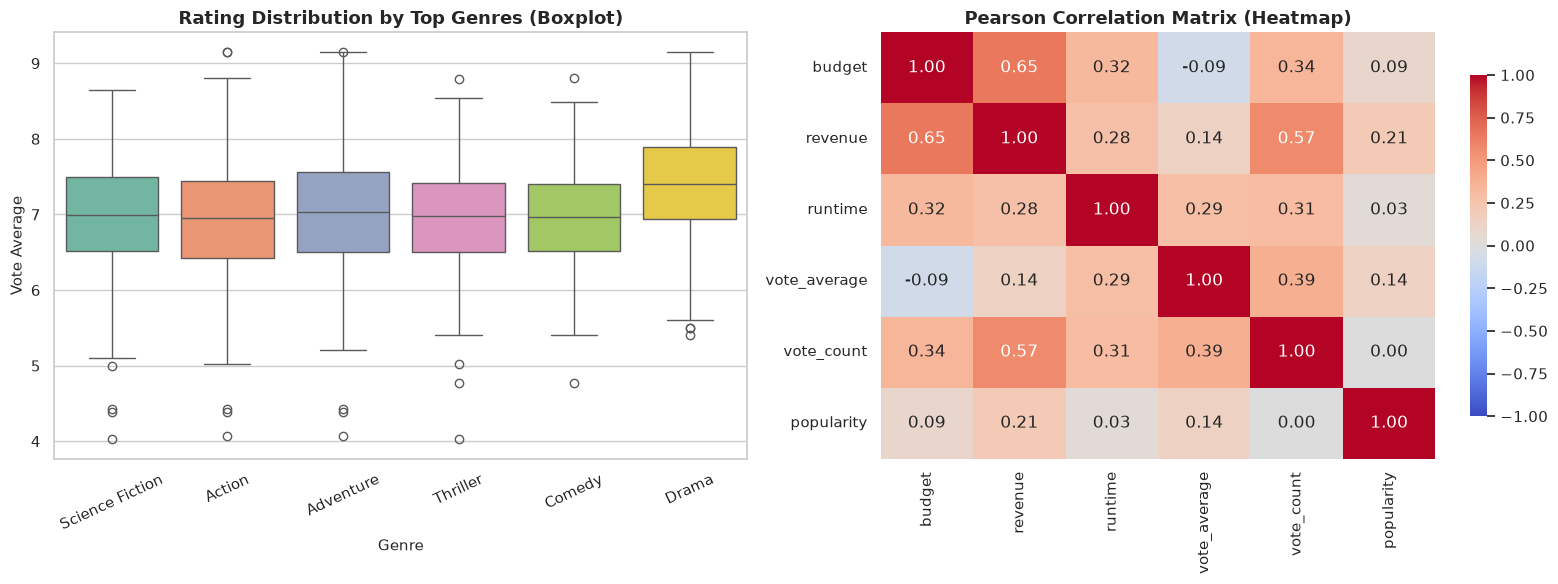

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot: Rating distributions across the top 6 genres
top_6_genres = ["Action", "Adventure", "Comedy", "Drama", "Thriller", "Science Fiction"]
df_genres = df.copy()
df_genres["genre_list"] = df_genres["genres"].dropna().str.split(", ")
df_exploded = df_genres.explode("genre_list")
df_top_genres = df_exploded[df_exploded["genre_list"].isin(top_6_genres)]

sns.boxplot(
    data=df_top_genres,
    x="genre_list",
    y="vote_average",
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Rating Distribution by Top Genres (Boxplot)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Genre", fontsize=11)
axes[0].set_ylabel("Vote Average", fontsize=11)
axes[0].tick_params(axis="x", rotation=25)

# 2. Correlation Heatmap across all numeric features
numeric_cols = ["budget", "revenue", "runtime", "vote_average", "vote_count", "popularity"]
corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=axes[1],
    cbar_kws={"shrink": 0.8}
)
axes[1].set_title("Pearson Correlation Matrix (Heatmap)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

### Interpretation - Chart 7:
- **Genre Boxplots**: **Drama** achieves the highest median rating (~7.3) with lower variance, while **Comedy** and **Action** show wider spreads and lower median scores (~6.8–7.0). Outliers (dots outside the whiskers) represent exceptional masterworks in each category.
- **Financial Synergy**: The strongest correlation in the dataset is between **budget and revenue (r = 0.63)**, followed by **vote_count and revenue (r = 0.54)** (blockbusters that make money also get voted on the most).
- **No Multicollinearity Hazard**: Most feature pairs have low to moderate correlations (r < 0.30), meaning our features provide distinct, complementary information for Machine Learning algorithms without risk of severe multicollinearity.